## Preprocessing pipeline for creating interaction prior based on scRNA-seq samples and Olink protein counts

last updated: 15.12.2025 <br>
original: 10.12.2025 <br>
HH

DIISCO model requires a prior interaction matrix that uses user specific threshold for gene counts. Also we would like to include protein level prior and using that in centering of interaction likelyhood. 

Olink bone marrow data is a bulk protein sequencing dataset form 71 ALL cases. The values are form two seperate batches that causes visible batch effect. Protein count is expressed in NPX form that is the normalized protein expression level. To get better understanding of the protein levels values need to be filtered based on limit of detection (LOD) value. With protein specific LOD value we can calculate more relative expression level NPX over LOD (NOL). It tells how much protein is expressed over the detection limit givingg cleare undeerstading of the kvantiative protien expression compared to other protiens in the set. The protine prior has been determined form three seperate timepoints.

Single cell RNA sequencing data (easi_data) has at been gathered from two seperate timepoints (dg and d15). Similarly to Olink data it is from the same bonemarrow samples. The values vill be filtered gene counts.



In [1]:
# packages (use omnipath_env!)
import pandas as pd
import scanpy as sc
import numpy as np
import seaborn as sns
import matplotlib as plt
import requests
import omnipath as op # for functioning numpy < version 2 and pyhton < version 12 (no other limitations found)
import warnings
import os
import anndata as an


c:\Users\heeki\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from itertools import product

In [3]:
# settings
warnings.filterwarnings("ignore")
#os.chdir("/research/groups/bioinformaticians/internship/hhuotari")

In [4]:
# paths
sample = 'EG11'
olink_path = 'data/Olink/Olink_bm/olink_all_bm_comb_Norm.csv' 
easi_data = f'easi_data/vireo_EGid_{sample}_filtered_s1.h5ad'
save_path = '/DIISCO/data'


In [5]:
olink_bm = pd.read_csv(olink_path)
# improve on (make into function)
sample = 'EG11'
easi_data = f'easi_data/vireo_EGid_{sample}_filtered_s1.h5ad'
EG11 = an.read_h5ad(easi_data)
print(easi_data)
sample = 'EG16'
easi_data = f'easi_data/vireo_EGid_{sample}_filtered_s1.h5ad'
EG16 = an.read_h5ad(easi_data)
print(easi_data)

easi_data/vireo_EGid_EG11_filtered_s1.h5ad
easi_data/vireo_EGid_EG16_filtered_s1.h5ad


In [6]:
# this will be made into function as only the table changes!
cell_groups_EG11 = EG11.obs['BmMap_anno_predicted_CellType_Broad'].unique() # more specific cellgroups: 'BmMap_anno_predicted_CellType'
genes_to_remove_EG11 = EG11.to_df(layer="log_normalized").columns[EG11.to_df(layer="log_normalized").sum()==0] # if sum = 0 -> gene can be assumed not to be present
EG11_gene_df = EG11.to_df(layer="log_normalized").drop(columns= genes_to_remove_EG11)

In [7]:
len(EG11.obs['BmMap_anno_predicted_CellType_Broad'])

773

In [8]:
celltype_expr = {}

for ct in cell_groups_EG11:
    rows = EG11[EG11.obs['BmMap_anno_predicted_CellType_Broad'] == ct].obs_names
    data_subset = EG11.to_df(layer="log_normalized")[EG11.to_df(layer="log_normalized").index.isin(rows)]
    
    if data_subset.shape[0] > 0:
        mean_exp = np.array(data_subset.mean(axis=0)).flatten()
    else:
        mean_exp = 0
    
    genes = EG11.to_df(layer="log_normalized").columns
    genes_to_remove = EG11.to_df(layer="log_normalized").columns[EG11.to_df(layer="log_normalized").sum()==0] 
    col_name = ct
    celltype_expr[col_name] = mean_exp
    
celltype_expr = pd.DataFrame.from_dict(celltype_expr)
celltype_expr = celltype_expr.set_index(genes) 
celltype_expr = celltype_expr.drop(index = genes_to_remove)
celltype_expr_EG11 = celltype_expr
    
    

In [9]:
pd.DataFrame.from_dict(celltype_expr_EG11)

,Pro-B,NK,Pre-B,Early Lymphoid,Naive T,CD4 Memory T,CD8 Memory T,nan,B,Plasma Cell,Monocyte,HSC MPP
RP11-34P13.7,0.004023,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
AL627309.1,0.003075,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
AP006222.2,0.035859,0.000000,0.013934,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
RP4-669L17.10,0.008795,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
RP11-206L10.3,0.034747,0.000000,0.021780,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
AL592183.1,0.406451,0.316854,0.317545,0.701263,0.320058,0.355658,0.579677,0.114107,0.349641,0.000000,0.0,0.0
AL354822.1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.652384,0.0,0.0
KIR2DL2,0.000000,1.027800,0.000000,0.000000,0.000000,0.000000,0.237418,0.000000,0.000000,0.000000,0.0,0.0
PNRC2.1,0.005120,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0


In [10]:
cell_groups_EG16 = EG16.obs['BmMap_anno_predicted_CellType_Broad'].unique() # more specific cellgroups: 'BmMap_anno_predicted_CellType'
genes_to_remove_EG16 = EG16.to_df(layer="log_normalized").columns[EG16.to_df(layer="log_normalized").sum()==0] 
EG16_gene_df = EG16.to_df(layer="log_normalized").drop(columns= genes_to_remove_EG16)

In [11]:
proprtions_EG11 = []

for ct in cell_groups_EG11:
    rows = len(EG11[EG11.obs['BmMap_anno_predicted_CellType_Broad'] == ct].obs_names)
    whole_set = len(EG11.obs['BmMap_anno_predicted_CellType_Broad'])
    poprotion = rows/whole_set

    proprtions_EG11.append({'Timepoint': 0, 'Celltype' : ct, 'Porprotions':poprotion}) 

proprtions_EG11 = pd.DataFrame(proprtions_EG11)

proprtions_EG16 = []

for ct in cell_groups_EG11:
    rows = len(EG16[EG16.obs['BmMap_anno_predicted_CellType_Broad'] == ct].obs_names)
    whole_set = len(EG16.obs['BmMap_anno_predicted_CellType_Broad'])
    poprotion = rows/whole_set

    proprtions_EG16.append({'Timepoint': 15, 'Celltype' : ct, 'Porprotions':poprotion}) 
    
proprtions_EG16 = pd.DataFrame(proprtions_EG16)

proportion = pd.concat([proprtions_EG11, proprtions_EG16])

In [12]:
proportion = proportion.pivot(index = 'Timepoint', columns = 'Celltype', values = 'Porprotions')

In [13]:
# interactions = op.interactions.AllInteractions.get()
# interactions_df = interactions[interactions.sources.isin(['CellChatDB'])]

In [14]:
interactions_df = op.interactions.import_intercell_network()
interactions_df = interactions_df.drop_duplicates()

For improved annotation HPA could be used to first groups gene/proteins in the target organ (bonemarrow/leukemia) and then continue to more indepth interaction scanning.

In [15]:
annotations = op.requests.Annotations.get(resources='CellChatDB')

In [16]:
prot_int_annot = annotations[annotations['entity_type']=='protein'] #later on complexes will be added
receptors = prot_int_annot[prot_int_annot['value']=='receptor']
ligands = prot_int_annot[prot_int_annot['value']=='ligand']

In [17]:
receptors_in_db = receptors[receptors['genesymbol'].isin(celltype_expr_EG11.index)]
celltype_expr_EG11['gene'] = celltype_expr_EG11.index
receptor_df = celltype_expr_EG11.merge(receptors_in_db, left_on='gene', right_on='genesymbol')
receptor_df = receptor_df.drop(columns= ['nan','genesymbol','entity_type','source', 'label', 'value', 'record_id'])
receptor_df.columns = ['target_' + col for col in receptor_df.columns]

In [18]:
ligands_in_db = ligands[ligands['genesymbol'].isin(celltype_expr_EG11.index)]
ligand_df = celltype_expr_EG11.merge(ligands_in_db, left_on='gene', right_on='genesymbol')
ligand_df = ligand_df.drop(columns= ['nan','genesymbol','entity_type','source', 'label', 'value', 'record_id'])
ligand_df.columns = ['source_' + col for col in ligand_df.columns]

In [19]:
interactions_df = interactions_df[['source','target']]
interactions_df = interactions_df.merge(ligand_df, left_on='source', right_on='source_uniprot')
interactions_df = interactions_df.merge(receptor_df, left_on='target', right_on='target_uniprot')
interactions_df = interactions_df.drop_duplicates()
interactions_df

,source,target,source_Pro-B,source_NK,source_Pre-B,source_Early Lymphoid,source_Naive T,source_CD4 Memory T,source_CD8 Memory T,source_B,...,target_Early Lymphoid,target_Naive T,target_CD4 Memory T,target_CD8 Memory T,target_B,target_Plasma Cell,target_Monocyte,target_HSC MPP,target_gene,target_uniprot
0,O00548,P46531,0.008910,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.759707,0.173688,0.000000,0.087981,0.108584,0.000000,0.613815,0.0,NOTCH1,P46531
32,P05019,P08069,0.003293,0.000000,0.032207,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,IGF1R,P08069
35,P78504,P46531,0.036554,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.759707,0.173688,0.000000,0.087981,0.108584,0.000000,0.613815,0.0,NOTCH1,P46531
75,Q9H2A7,O00574,0.036192,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.560912,0.049014,0.000000,0.000000,0.000000,0.0,CXCR6,O00574
77,P49771,P36888,0.025087,0.000000,0.039393,0.000000,0.613556,0.564392,0.240353,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,FLT3,P36888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14286,P01375,P29317,0.084251,0.053978,0.227176,0.000000,0.000000,0.181651,0.073486,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,EPHA2,P29317
14294,P28799,P29317,0.132356,0.020309,0.151356,0.346874,0.000000,0.000000,0.021023,0.539067,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,EPHA2,P29317
14302,P01133,P35613,0.005004,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.414983,0.442742,0.903469,0.656463,0.145983,0.000000,0.613815,0.0,BSG,P35613
14308,P01133,P11717,0.005004,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.701263,0.000000,0.547361,0.546773,0.000000,1.652384,0.000000,0.0,IGF2R,P11717


### Adding protein information to the interaction table

In [20]:
olink_bm['Disease'].unique()

array(['ALL', 'treatment_toxicity', 'control', 'non-leukemic'],
      dtype=object)

In [21]:
# Filtering protein table based on limit of detection values LOD
olink_bm = olink_bm[olink_bm['Disease']=='ALL']
olink_bm['NOL'] = (
    olink_bm['NPX'] - olink_bm['FixedLOD']
)
olink_bm['NOL'] = olink_bm['NOL'].clip(lower=0)
protein_df = olink_bm

In [22]:
# Protiens in matching patient sample ALLK-112
protein_df_112_df = protein_df[protein_df['Patient_ID']=='ALLK-112']
protein_df_112 = protein_df_112_df.pivot(columns='Assay', index = 'Timepoint',values='NOL')
proteins_to_remove = protein_df_112.columns[protein_df_112.median()<=0]

# removing protiens with median smaller than 0
# in this case it means that the protein is not present in two or more samples.
protein_df_112 = protein_df_112.drop(columns=proteins_to_remove)
proteins = protein_df_112.columns
protein_df_112 =protein_df_112.melt()
protein_df_112 = protein_df_112.merge(protein_df_112_df, right_on='Assay', left_on = 'Assay')[['Timepoint', 'NOL','Assay', 'UniProt']].drop_duplicates()

Changing protein id to genes. This is done to match the genes and proteins to each other


In [23]:
# from UniProt API 
import re
import time
import zlib
from xml.etree import ElementTree
from urllib.parse import urlparse, parse_qs, urlencode
import requests
from requests.adapters import HTTPAdapter, Retry

POLLING_INTERVAL = 10
API_URL = "https://rest.uniprot.org"


retries = Retry(total=5, backoff_factor=0.25, status_forcelist=[500, 502, 503, 504])
session = requests.Session()
session.mount("https://", HTTPAdapter(max_retries=retries))

In [24]:
# from uniprot API
def check_response(response):
    try:
        response.raise_for_status()
    except requests.HTTPError:
        print(response.json())
        raise


def submit_id_mapping(from_db, to_db, ids):
    request = requests.post(
        f"{API_URL}/idmapping/run",
        data={"from": from_db, "to": to_db, "ids": ids, 'taxId':"9606"}, # taxID refers to human so this code is for human samples. This can be changed by using different taxonomy id
    )
    check_response(request)
    return request.json()["jobId"]


def get_next_link(headers):
    re_next_link = re.compile(r'<(.+)>; rel="next"')
    if "Link" in headers:
        match = re_next_link.match(headers["Link"])
        if match:
            return match.group(1)


def check_id_mapping_results_ready(job_id):
    while True:
        request = session.get(f"{API_URL}/idmapping/status/{job_id}")
        check_response(request)
        j = request.json()
        if "jobStatus" in j:
            if j["jobStatus"] in ("NEW", "RUNNING"):
                print(f"Retrying in {POLLING_INTERVAL}s")
                time.sleep(POLLING_INTERVAL)
            else:
                raise Exception(j["jobStatus"])
        else:
            return bool(j["results"] or j["failedIds"])


def get_batch(batch_response, file_format, compressed):
    batch_url = get_next_link(batch_response.headers)
    while batch_url:
        batch_response = session.get(batch_url)
        batch_response.raise_for_status()
        yield decode_results(batch_response, file_format, compressed)
        batch_url = get_next_link(batch_response.headers)


def combine_batches(all_results, batch_results, file_format):
    if file_format == "json":
        for key in ("results", "failedIds"):
            if key in batch_results and batch_results[key]:
                all_results[key] += batch_results[key]
    elif file_format == "tsv":
        return all_results + batch_results[1:]
    else:
        return all_results + batch_results
    return all_results


def get_id_mapping_results_link(job_id):
    url = f"{API_URL}/idmapping/details/{job_id}"
    request = session.get(url)
    check_response(request)
    return request.json()["redirectURL"]


def decode_results(response, file_format, compressed):
    if compressed:
        decompressed = zlib.decompress(response.content, 16 + zlib.MAX_WBITS)
        if file_format == "json":
            j = json.loads(decompressed.decode("utf-8"))
            return j
        elif file_format == "tsv":
            return [line for line in decompressed.decode("utf-8").split("\n") if line]
        elif file_format == "xlsx":
            return [decompressed]
        elif file_format == "xml":
            return [decompressed.decode("utf-8")]
        else:
            return decompressed.decode("utf-8")
    elif file_format == "json":
        return response.json()
    elif file_format == "tsv":
        return [line for line in response.text.split("\n") if line]
    elif file_format == "xlsx":
        return [response.content]
    elif file_format == "xml":
        return [response.text]
    return response.text


def get_xml_namespace(element):
    m = re.match(r"\{(.*)\}", element.tag)
    return m.groups()[0] if m else ""


def merge_xml_results(xml_results):
    merged_root = ElementTree.fromstring(xml_results[0])
    for result in xml_results[1:]:
        root = ElementTree.fromstring(result)
        for child in root.findall("{http://uniprot.org/uniprot}entry"): 
            merged_root.insert(-1, child)
    ElementTree.register_namespace("", get_xml_namespace(merged_root[0]))
    return ElementTree.tostring(merged_root, encoding="utf-8", xml_declaration=True)


def print_progress_batches(batch_index, size, total):
    n_fetched = min((batch_index + 1) * size, total)
    print(f"Fetched: {n_fetched} / {total}")


def get_id_mapping_results_search(url):
    parsed = urlparse(url)
    query = parse_qs(parsed.query)
    file_format = query["format"][0] if "format" in query else "json"
    if "size" in query:
        size = int(query["size"][0])
    else:
        size = 500
        query["size"] = size
    compressed = (
        query["compressed"][0].lower() == "true" if "compressed" in query else False
    )
    parsed = parsed._replace(query=urlencode(query, doseq=True))
    url = parsed.geturl()
    request = session.get(url)
    check_response(request)
    results = decode_results(request, file_format, compressed)
    total = int(request.headers["x-total-results"])
    print_progress_batches(0, size, total)
    for i, batch in enumerate(get_batch(request, file_format, compressed), 1):
        results = combine_batches(results, batch, file_format)
        print_progress_batches(i, size, total)
    if file_format == "xml":
        return merge_xml_results(results)
    return results


def get_id_mapping_results_stream(url):
    if "/stream/" not in url:
        url = url.replace("/results/", "/results/stream/")
    request = session.get(url)
    check_response(request)
    parsed = urlparse(url)
    query = parse_qs(parsed.query)
    file_format = query["format"][0] if "format" in query else "json"
    compressed = (
        query["compressed"][0].lower() == "true" if "compressed" in query else False
    )
    return decode_results(request, file_format, compressed)

# modified from UniProt API
def from_protein_to_gene_uniprot(ids):
    job_id = submit_id_mapping(
    from_db="UniProtKB_AC-ID", to_db="Gene_Name", ids=ids
    )
    if check_id_mapping_results_ready(job_id):
        link = get_id_mapping_results_link(job_id)
        results = get_id_mapping_results_search(link)
    return(results)

def from_protein_to_protien_id(ids):
    job_id = submit_id_mapping(
    from_db="UniProtKB_AC-ID", to_db="UniProtKB", ids=ids
    )
    if check_id_mapping_results_ready(job_id):
        link = get_id_mapping_results_link(job_id)
        results = get_id_mapping_results_search(link)
    return(results)


In [25]:
def mapping_proteins(protein_list):
    
    protein_list = [p+'_HUMAN' for p in protein_list] # Uniprot need a species specifier for the mapper to work
    mapping_result = from_protein_to_gene_uniprot(protein_list)
    prot=[]
    gene=[]
    for i in range(len(mapping_result['results'])):
        gene.append(mapping_result['results'][i]['to'])
        prot.append(mapping_result['results'][i]['from'])

    prot=[re.sub('_HUMAN', '', p) for p in prot]

    gene_to_protein = pd.DataFrame({'genes':gene,'proteins': prot})

    return gene_to_protein


def mapping_protein_IDs(protein_list):
    
    protein_list = [p+'_HUMAN' for p in protein_list] # Uniprot need a species specifier for the mapper to work
    mapping_result = from_protein_to_protien_id(protein_list)
    prot=[]
    gene=[]
    return (mapping_result)
    # for i in range(len(mapping_result['results'])):
    #     gene.append(mapping_result['results'][i]['to'])
    #     prot.append(mapping_result['results'][i]['from'])

    # prot=[re.sub('_HUMAN', '', p) for p in prot]

    # gene_to_protein = pd.DataFrame({'genes':gene,'proteins': prot})

    # return gene_to_protein

In [26]:
protein_gene_df = mapping_proteins(proteins)
# 1194 proteins remaining out of 2417 (should be checked again!)

Fetched: 500 / 1194
Fetched: 1000 / 1194
Fetched: 1194 / 1194


In [27]:
interactions_df['ligand_as_protein'] = interactions_df['source'].isin(protein_df_112['UniProt']) # if genes convertet wiht UniprotAPI, counts can be used
interactions_df['receptor_as_protein'] = interactions_df['target'].isin(protein_df_112['UniProt'])
interactions_df = interactions_df.drop(columns = interactions_df.columns[interactions_df.sum()==0])


In [28]:
from collections import Counter

In [29]:
interactions_summary = interactions_df.drop(columns = ['source', 'target','source_gene', 'source_uniprot','target_gene', 'target_uniprot',
       'ligand_as_protein', 'receptor_as_protein'])

interaction_pairs = []

for row in range(0,len(interactions_summary.index)):
    i = interactions_summary.columns[interactions_summary.iloc[row,:]>0.001]
    sources = [c.replace('source_', '') for c in i if c.startswith('source_')]
    targets = [c.replace('target_', '') for c in i if c.startswith('target_')]
    
    pairs = list(product(sources, targets))
    interaction_pairs.extend(pairs)
    
pair_counts = Counter(interaction_pairs)

In [30]:
df_counts = pd.DataFrame(
    [(s, t, c) for (s, t), c in pair_counts.items()],
    columns=['source_cell', 'target_cell', 'count']
)
matrix = df_counts.pivot(
    index='source_cell',
    columns='target_cell',
    values='count'
).fillna(0)

binary_matrix = df_counts.pivot(
    index='source_cell',
    columns='target_cell',
    values='count'
).fillna(0)


binary_matrix[binary_matrix < 100] = 0
binary_matrix[binary_matrix >= 100] = 1

<Axes: xlabel='target_cell', ylabel='source_cell'>

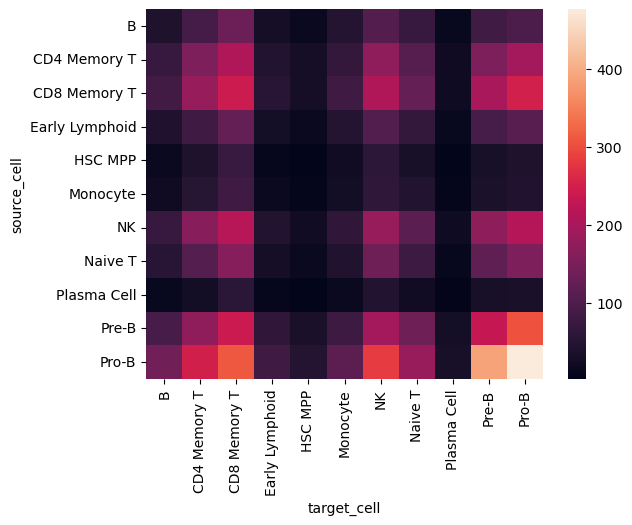

In [31]:
sns.heatmap(matrix)

<Axes: xlabel='target_cell', ylabel='source_cell'>

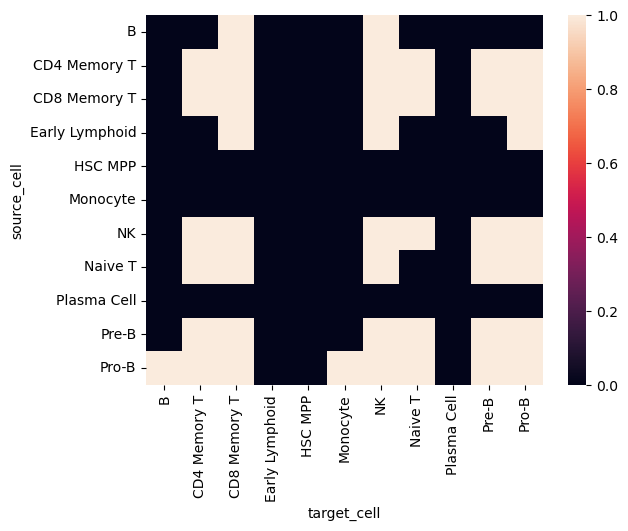

In [32]:
sns.heatmap(binary_matrix)

In [33]:
W = proportion[binary_matrix.columns]

In [34]:
for row in interactions_df:
    interactions_df
    certain_interactions = interactions_df[interactions_df['receptor_as_protein']]
    certain_interactions = certain_interactions[certain_interactions['ligand_as_protein']]
certain_interactions.source.iloc[:50].values




array(['O00548', 'O43557', 'P01375', 'P32970', 'P48023', 'O00182',
       'P06239', 'P61812', 'P06239', 'P01584', 'P01137', 'O00548',
       'P06239', 'P20827', 'P20827', 'P20827', 'Q14393', 'Q99075',
       'P21741', 'Q9GZP0', 'P52798', 'P52798', 'P06239', 'Q14393',
       'P01127', 'P15692', 'P14174', 'P06239', 'P00749', 'P06239',
       'P01375', 'O43557', 'P98160', 'P30203', 'P09326', 'O75144',
       'Q14005', 'P05067', 'P06734', 'P06734', 'Q02487', 'P52798',
       'P01135', 'P49763', 'P13688', 'P57087', 'Q9Y624', 'Q6GTX8',
       'P46379', 'Q9BQ51'], dtype=object)

In [35]:

from collections import Counter

certain_summary = certain_interactions.drop(columns = ['source', 'target','source_gene', 'source_uniprot','target_gene', 'target_uniprot',
       'ligand_as_protein', 'receptor_as_protein'])
interaction_pairs = []

for row in range(0,len(certain_summary.index)):
    i = certain_summary.columns[certain_summary.iloc[row,:]>0.001]
    sources = [c.replace('source_', '') for c in i if c.startswith('source_')]
    targets = [c.replace('target_', '') for c in i if c.startswith('target_')]
    
    pairs = list(product(sources, targets))
    interaction_pairs.extend(pairs)
real_pair_counts = Counter(interaction_pairs)

r_df_counts = pd.DataFrame(
    [(s, t, c) for (s, t), c in real_pair_counts.items()],
    columns=['source_cell', 'target_cell', 'count']
)

r_matrix = r_df_counts.pivot(
    index='source_cell',
    columns='target_cell',
    values='count'
).fillna(0)

r_binary_matrix = r_df_counts.pivot(
    index='source_cell',
    columns='target_cell',
    values='count'
).fillna(0)

real_pair_counts


Counter({('Pro-B', 'Pro-B'): 114,
         ('Pro-B', 'Pre-B'): 92,
         ('Pre-B', 'Pro-B'): 88,
         ('CD8 Memory T', 'Pro-B'): 70,
         ('Pre-B', 'Pre-B'): 68,
         ('Pro-B', 'CD8 Memory T'): 66,
         ('Pre-B', 'CD8 Memory T'): 60,
         ('CD4 Memory T', 'Pro-B'): 60,
         ('Pro-B', 'CD4 Memory T'): 59,
         ('CD8 Memory T', 'Pre-B'): 58,
         ('CD8 Memory T', 'CD8 Memory T'): 57,
         ('NK', 'Pro-B'): 56,
         ('Pro-B', 'NK'): 55,
         ('NK', 'CD8 Memory T'): 52,
         ('Pre-B', 'CD4 Memory T'): 51,
         ('NK', 'Pre-B'): 49,
         ('CD4 Memory T', 'CD8 Memory T'): 49,
         ('CD8 Memory T', 'CD4 Memory T'): 49,
         ('CD4 Memory T', 'Pre-B'): 49,
         ('Pre-B', 'NK'): 47,
         ('NK', 'CD4 Memory T'): 44,
         ('CD8 Memory T', 'NK'): 44,
         ('Pro-B', 'Naive T'): 42,
         ('CD4 Memory T', 'CD4 Memory T'): 42,
         ('Naive T', 'Pro-B'): 41,
         ('Naive T', 'CD8 Memory T'): 40,
         ('Pre-B

In [36]:

for i  in range(0, r_matrix.shape[0]):
    mask = r_binary_matrix.iloc[i] < r_matrix.mean()[i]
    r_binary_matrix.iloc[i, mask] = 0
    r_binary_matrix.iloc[i, ~mask] = 1

Text(0.5, 1.0, 'Interaction mtrix based on proteins')

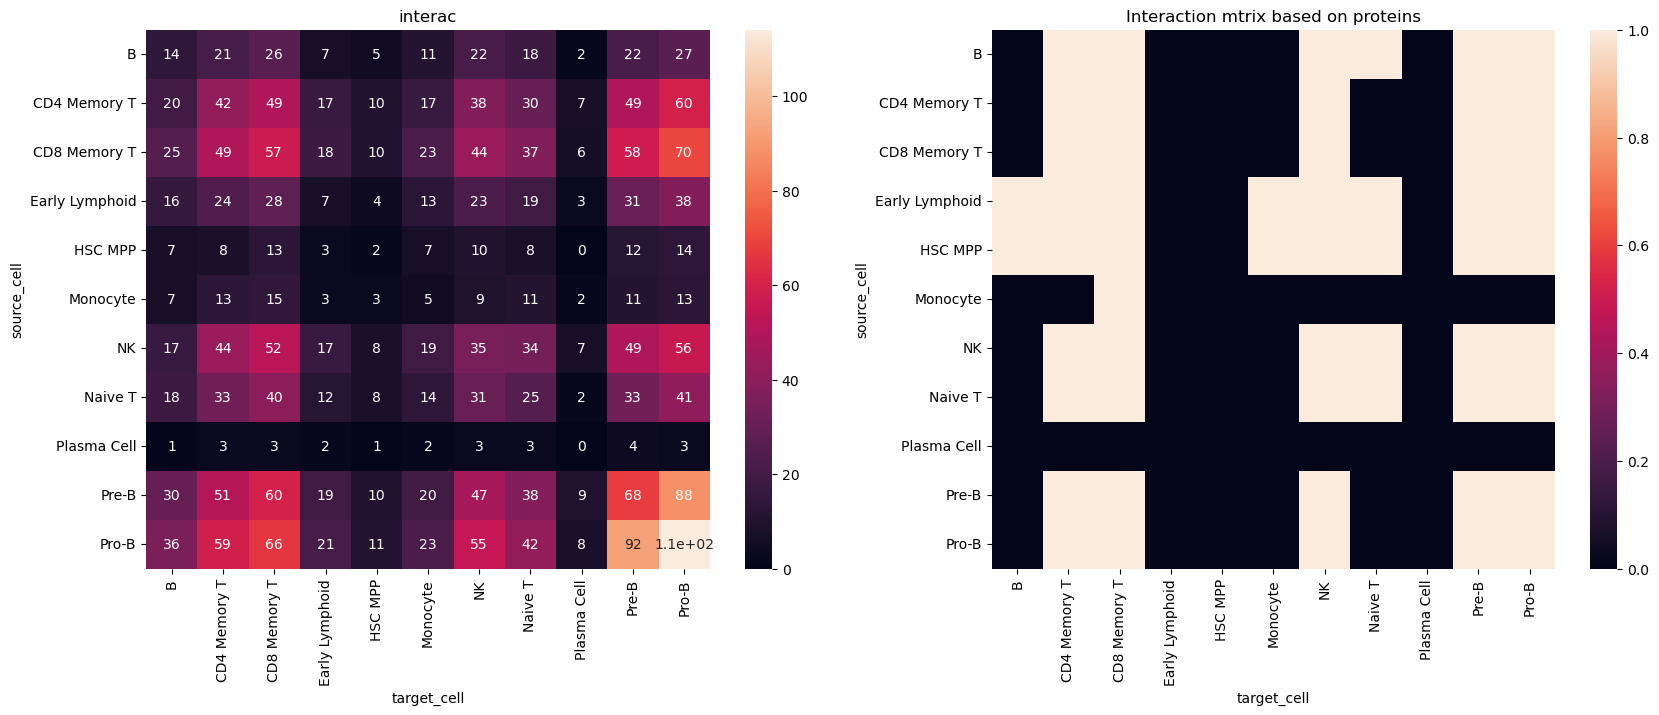

In [37]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(r_matrix, annot = True, ax = axes[0])
sns.heatmap(r_binary_matrix, ax = axes[1])
axes[0].set_title('interac')
axes[1].set_title('Interaction mtrix based on proteins')

In [38]:
protein_df_112  = protein_df_112.merge(protein_gene_df, left_on = 'Assay',right_on='proteins')
protein_df = protein_df_112[['Timepoint', 'NOL', 'proteins', 'genes']]

In [39]:
protein_df_112

,Timepoint,NOL,Assay,UniProt,genes,proteins
0,dg,3.759767,A1BG,P04217,A1BG,A1BG
1,d29,3.021045,A1BG,P04217,A1BG,A1BG
2,d15,2.632788,A1BG,P04217,A1BG,A1BG
3,dg,1.002793,AAAS,Q9NRG9,AAAS,AAAS
4,d29,0.620126,AAAS,Q9NRG9,AAAS,AAAS
...,...,...,...,...,...,...
3577,d29,5.147754,ZMAT3,Q9HA38,ZMAT3,ZMAT3
3578,d15,6.003165,ZMAT3,Q9HA38,ZMAT3,ZMAT3
3579,dg,0.581688,ZP3,P21754,ZP3,ZP3
3580,d29,0.995085,ZP3,P21754,ZP3,ZP3


In [40]:
certain_interactions

,source,target,source_Pro-B,source_NK,source_Pre-B,source_Early Lymphoid,source_Naive T,source_CD4 Memory T,source_CD8 Memory T,source_B,...,target_CD4 Memory T,target_CD8 Memory T,target_B,target_Plasma Cell,target_Monocyte,target_HSC MPP,target_gene,target_uniprot,ligand_as_protein,receptor_as_protein
0,O00548,P46531,0.008910,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.087981,0.108584,0.000000,0.613815,0.0,NOTCH1,P46531,True,True
121,O43557,P36941,0.000000,0.076466,0.000000,0.000000,0.000000,0.000000,0.078114,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.881187,0.0,LTBR,P36941,True,True
192,P01375,P20333,0.084251,0.053978,0.227176,0.000000,0.000000,0.181651,0.073486,0.000000,...,0.880411,0.739931,0.097555,0.000000,0.613815,0.0,TNFRSF1B,P20333,True,True
206,P32970,P26842,0.108396,0.000000,0.125936,0.000000,0.000000,0.108806,0.000000,0.000000,...,1.995131,1.008255,0.379651,1.652384,0.000000,0.0,CD27,P26842,True,True
218,P48023,P25445,0.000000,0.192624,0.000000,0.000000,0.000000,0.069794,0.165121,0.000000,...,0.418339,0.057005,0.000000,0.000000,0.000000,0.0,FAS,P25445,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14252,P50591,P25445,0.014491,0.272756,0.006638,0.000000,0.166365,0.836800,0.183361,0.000000,...,0.418339,0.057005,0.000000,0.000000,0.000000,0.0,FAS,P25445,True,True
14281,P15692,Q16625,0.028890,0.000000,0.054947,0.414983,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,OCLN,Q16625,True,True
14286,P01375,P29317,0.084251,0.053978,0.227176,0.000000,0.000000,0.181651,0.073486,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,EPHA2,P29317,True,True
14294,P28799,P29317,0.132356,0.020309,0.151356,0.346874,0.000000,0.000000,0.021023,0.539067,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,EPHA2,P29317,True,True


In [41]:
# Getting source and target genes to match protein information to:
gene_table = certain_interactions[['source_gene', 'target_gene']]
target = protein_df[protein_df['genes'].isin(gene_table['target_gene'])]
source = protein_df[protein_df['genes'].isin(gene_table['source_gene'])]
gene_table = gene_table.merge(target, left_on = 'target_gene', right_on='genes').drop(columns = ['genes','proteins'])
gene_table = gene_table.merge(source, left_on = ['source_gene','Timepoint'], right_on=['genes','Timepoint']).drop(columns = ['genes','proteins'])

In [42]:
protein_df_112

,Timepoint,NOL,Assay,UniProt,genes,proteins
0,dg,3.759767,A1BG,P04217,A1BG,A1BG
1,d29,3.021045,A1BG,P04217,A1BG,A1BG
2,d15,2.632788,A1BG,P04217,A1BG,A1BG
3,dg,1.002793,AAAS,Q9NRG9,AAAS,AAAS
4,d29,0.620126,AAAS,Q9NRG9,AAAS,AAAS
...,...,...,...,...,...,...
3577,d29,5.147754,ZMAT3,Q9HA38,ZMAT3,ZMAT3
3578,d15,6.003165,ZMAT3,Q9HA38,ZMAT3,ZMAT3
3579,dg,0.581688,ZP3,P21754,ZP3,ZP3
3580,d29,0.995085,ZP3,P21754,ZP3,ZP3


In [43]:
potein_table = certain_interactions[['source', 'target']]
target = protein_df_112[protein_df_112['UniProt'].isin(potein_table['target'])]
source = protein_df_112[protein_df_112['UniProt'].isin(potein_table['source'])]
potein_table = potein_table.merge(target, left_on = 'target', right_on='UniProt').drop(columns = ['UniProt'])
potein_table = potein_table.merge(source, left_on = ['source','Timepoint'], right_on=['UniProt','Timepoint']).drop(columns = ['UniProt'])

potein_table = potein_table.rename(
    columns={'NOL_x': 'NOL_target', 'NOL_y': 'NOL_source', 'Assay_x': 'target_gene', 'Assay_y': 'source_gene'}
)

In [44]:
potein_table

,source,target,Timepoint,NOL_target,target_gene,genes_x,proteins_x,NOL_source,source_gene,genes_y,proteins_y
0,P32970,P26842,dg,9.016682,CD27,CD27,CD27,5.197251,CD70,CD70,CD70
1,P32970,P26842,d29,4.999990,CD27,CD27,CD27,1.924860,CD70,CD70,CD70
2,P32970,P26842,d15,2.999392,CD27,CD27,CD27,0.501387,CD70,CD70,CD70
3,P06239,P01732,dg,4.028136,CD8A,CD8A,CD8A,5.432959,LCK,LCK,LCK
4,P06239,P01732,d29,2.498964,CD8A,CD8A,CD8A,2.303846,LCK,LCK,LCK
...,...,...,...,...,...,...,...,...,...,...,...
190,P28799,P29317,d29,2.922399,EPHA2,EPHA2,EPHA2,4.004582,GRN,GRN,GRN
191,P28799,P29317,d15,2.235358,EPHA2,EPHA2,EPHA2,3.695106,GRN,GRN,GRN
192,P04083,Q15303,dg,1.055759,ERBB4,ERBB4,ERBB4,1.752755,ANXA1,ANXA1,ANXA1
193,P04083,Q15303,d29,0.591221,ERBB4,ERBB4,ERBB4,4.086014,ANXA1,ANXA1,ANXA1


In [45]:
certain_interactions['column_id'] = certain_interactions.index

In [46]:
certain_interactions

,source,target,source_Pro-B,source_NK,source_Pre-B,source_Early Lymphoid,source_Naive T,source_CD4 Memory T,source_CD8 Memory T,source_B,...,target_CD8 Memory T,target_B,target_Plasma Cell,target_Monocyte,target_HSC MPP,target_gene,target_uniprot,ligand_as_protein,receptor_as_protein,column_id
0,O00548,P46531,0.008910,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.087981,0.108584,0.000000,0.613815,0.0,NOTCH1,P46531,True,True,0
121,O43557,P36941,0.000000,0.076466,0.000000,0.000000,0.000000,0.000000,0.078114,0.000000,...,0.000000,0.000000,0.000000,0.881187,0.0,LTBR,P36941,True,True,121
192,P01375,P20333,0.084251,0.053978,0.227176,0.000000,0.000000,0.181651,0.073486,0.000000,...,0.739931,0.097555,0.000000,0.613815,0.0,TNFRSF1B,P20333,True,True,192
206,P32970,P26842,0.108396,0.000000,0.125936,0.000000,0.000000,0.108806,0.000000,0.000000,...,1.008255,0.379651,1.652384,0.000000,0.0,CD27,P26842,True,True,206
218,P48023,P25445,0.000000,0.192624,0.000000,0.000000,0.000000,0.069794,0.165121,0.000000,...,0.057005,0.000000,0.000000,0.000000,0.0,FAS,P25445,True,True,218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14252,P50591,P25445,0.014491,0.272756,0.006638,0.000000,0.166365,0.836800,0.183361,0.000000,...,0.057005,0.000000,0.000000,0.000000,0.0,FAS,P25445,True,True,14252
14281,P15692,Q16625,0.028890,0.000000,0.054947,0.414983,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,OCLN,Q16625,True,True,14281
14286,P01375,P29317,0.084251,0.053978,0.227176,0.000000,0.000000,0.181651,0.073486,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.0,EPHA2,P29317,True,True,14286
14294,P28799,P29317,0.132356,0.020309,0.151356,0.346874,0.000000,0.000000,0.021023,0.539067,...,0.000000,0.000000,0.000000,0.000000,0.0,EPHA2,P29317,True,True,14294


In [47]:

s_cols = [c for c in certain_interactions.columns if c.startswith('source_')] 
t_cols = [c for c in certain_interactions.columns if c.startswith('target_')]


In [48]:
# s_long = certain_interactions.melt(
#     id_vars=['source_gene', 'target_gene','column_id'],
#     value_vars=s_cols, # the values will be over written later
#     var_name='source_cell',
# )
# s_long['source_cell'] = s_long['source_cell'].str.replace('source_', '')

# t_long = certain_interactions.melt(
#     id_vars=['source_gene', 'target_gene','column_id'],
#     value_vars=t_cols, # the values will be over written later
#     var_name='target_cell',

# )

# t_long['target_cell'] = t_long['target_cell'].str.replace('target_', '')

In [49]:

# int_df = s_long.merge(t_long, left_on=['source_gene','target_gene','column_id'], right_on =['source_gene','target_gene','column_id'])
# int_df=int_df[(int_df['target_cell']!='uniprot') & (int_df['source_cell']!='uniprot') & (int_df['value_x']!=0) & int_df['value_y']!=0]

# int_df = int_df.merge(gene_table, left_on=['source_gene','target_gene'], right_on =['source_gene','target_gene']).drop(columns=['column_id']).drop_duplicates()

In [50]:
# Uniprot ID
s_long = certain_interactions.melt(
    id_vars=['source', 'target','column_id'],
    value_vars=s_cols, # the values will be over written later
    var_name='source_cell',
)
s_long['source_cell'] = s_long['source_cell'].str.replace('source_', '')

t_long = certain_interactions.melt(
    id_vars=['source', 'target','column_id'],
    value_vars=t_cols, # the values will be over written later
    var_name='target_cell',

)

t_long['target_cell'] = t_long['target_cell'].str.replace('target_', '')

In [51]:
int_df = s_long.merge(t_long, left_on=['source','target','column_id'], right_on =['source','target','column_id'])
int_df=int_df[(int_df['target_cell']!='gene') & (int_df['source_cell']!='gene') & (int_df['target_cell']!='uniprot') & (int_df['source_cell']!='uniprot') &(int_df['value_x']!=0) & int_df['value_y']!=0]
int_df = int_df.merge(potein_table, left_on=['source','target'], right_on =['source','target']).drop(columns=['column_id']).drop_duplicates()

In [52]:
int_df_dg = int_df[int_df['Timepoint']=='dg']
int_df_d15 = int_df[int_df['Timepoint']=='d15']
int_df_d29 = int_df[int_df['Timepoint']=='d29']

In [53]:

from scipy.stats import pearsonr
celltype = int_df['target_cell'].unique()
# fig, axes = plt.subplots(len(celltype), len(celltype), figsize=(25, 20))

correlations = []
for x in range(0,len(celltype)):
    i = celltype[x]
    for y in range(len(celltype)):
        j = celltype[y]
        df = int_df[(int_df['target_cell'] == i) & (int_df['source_cell'] == j)]
        cell_pair = f'{i}, {j}'
        
        if len(df) > 1:
            corr, p_value = pearsonr(df['NOL_target'], df['NOL_source'])
            
            # sns.regplot(
            # x='NOL_target', y='NOL_source', data=df, ax=axes[x, y], line_kws={'color': 'black'})
            # axes[x, y].set_title(f'{cell_pair}', size = 10)  
            # # axes[x, y].tick_params(labelbottom=False, labelleft=False)
            # axes[x, y].set(xlabel=None, ylabel=None)
            # axes[x, y].text(0.7, 0.95, f"r = {corr:.2f}\np = {p_value:.2g}", transform=axes[x, y].transAxes,
            # ha='left', va='top', fontsize=7)     
            # axes[x,y].set_xlim(0,8)   
            # axes[x,y].set_ylim(0,8)   
            
        else:
            corr = 0
            p_value = 0
            
        correlations.append({'interaction': cell_pair, 'target':i, 'souce':j, 'correlation' : corr, 'p-val' : p_value})
        
        
correlations = pd.DataFrame(correlations)   
plt.tight_layout() 

<Figure size 640x480 with 0 Axes>

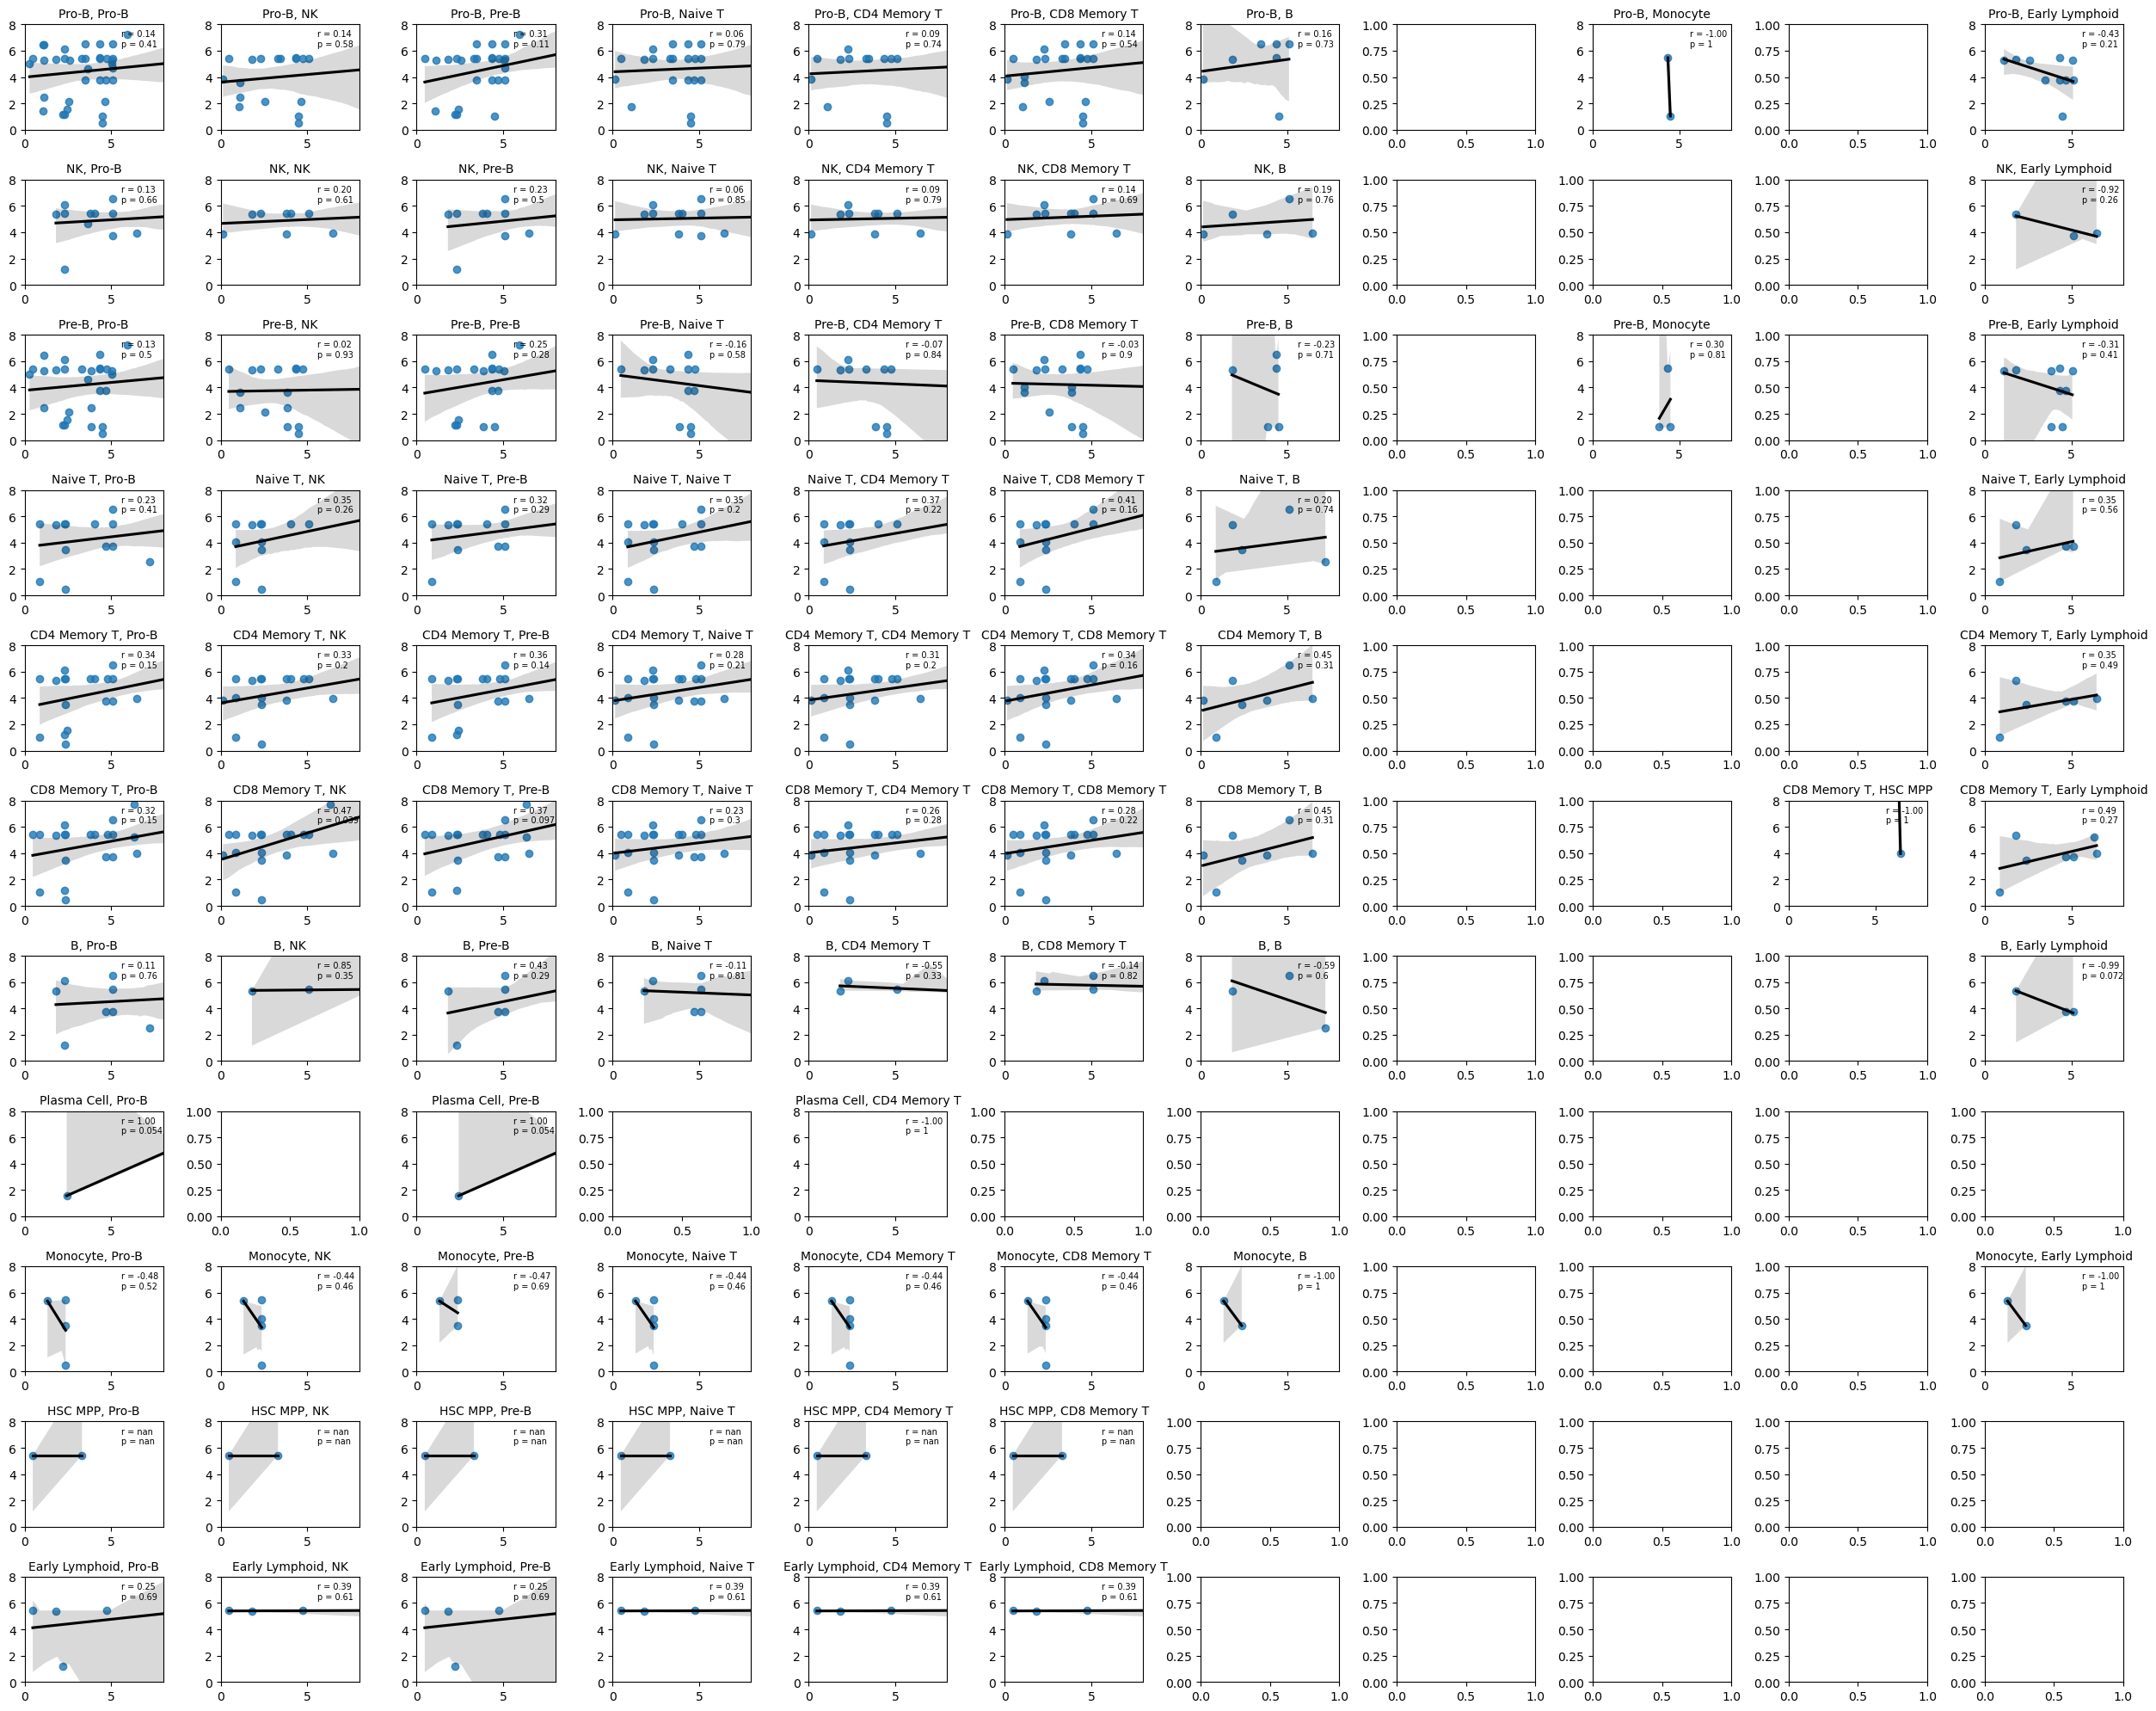

In [54]:

from scipy.stats import pearsonr
celltype = int_df_dg['target_cell'].unique()
fig, axes = plt.subplots(len(celltype), len(celltype), figsize=(25, 20))

correlations_dg = []
for x in range(0,len(celltype)):
    i = celltype[x]
    for y in range(len(celltype)):
        j = celltype[y]
        df = int_df_dg[(int_df_dg['target_cell'] == i) & (int_df_dg['source_cell'] == j)]
        cell_pair = f'{i}, {j}'
        
        if len(df) > 1:
            corr, p_value = pearsonr(df['NOL_target'], df['NOL_source'])
            
            sns.regplot(
            x='NOL_target', y='NOL_source', data=df, ax=axes[x, y], line_kws={'color': 'black'})
            axes[x, y].set_title(f'{cell_pair}', size = 10)  
            # axes[x, y].tick_params(labelbottom=False, labelleft=False)
            axes[x, y].set(xlabel=None, ylabel=None)
            axes[x, y].text(0.7, 0.95, f"r = {corr:.2f}\np = {p_value:.2g}", transform=axes[x, y].transAxes,
            ha='left', va='top', fontsize=7)     
            axes[x,y].set_xlim(0,8)   
            axes[x,y].set_ylim(0,8)   
            
        else:
            corr = 0
            p_value = 0
            
        correlations_dg.append({'interaction': cell_pair, 'target':i, 'souce':j, 'correlation' : corr, 'p-val' : p_value})
        
        
correlations_dg = pd.DataFrame(correlations_dg)   
plt.tight_layout()    

        

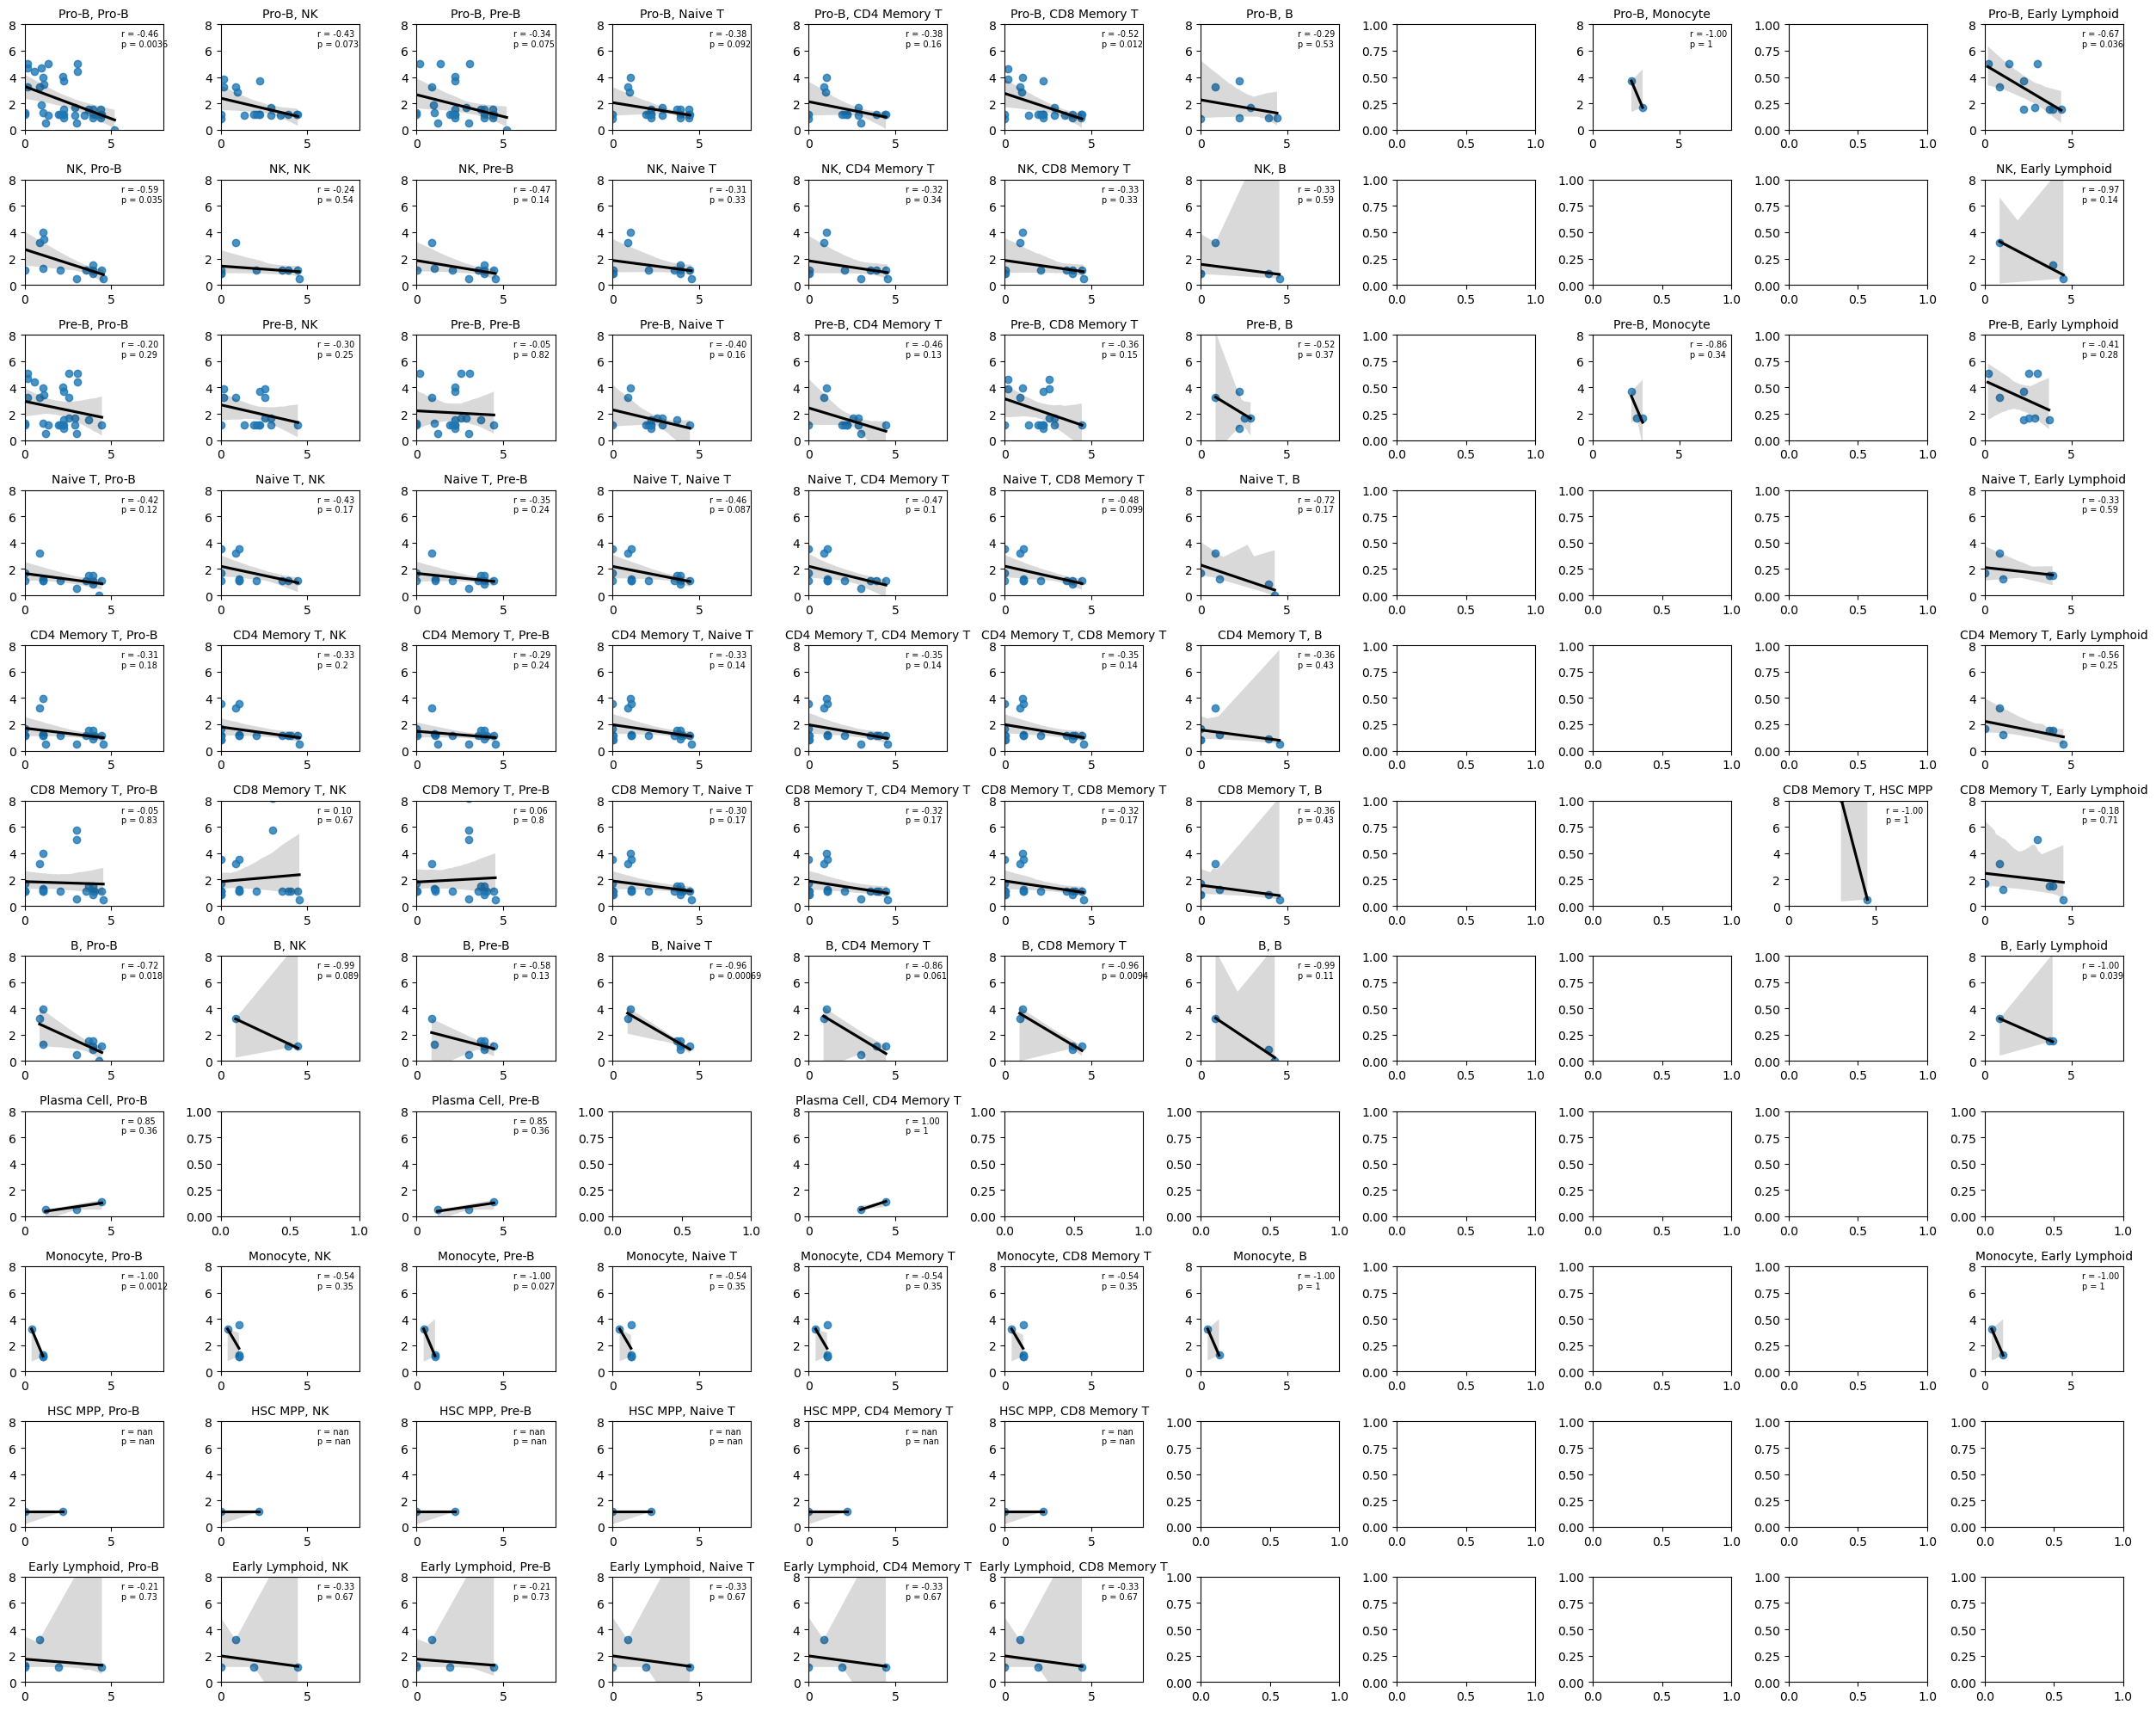

In [55]:
from scipy.stats import pearsonr
celltype = int_df_d15['target_cell'].unique()
fig, axes = plt.subplots(len(celltype), len(celltype), figsize=(25, 20))

correlations_d15 = []
for x in range(0,len(celltype)):
    i = celltype[x]
    for y in range(len(celltype)):
        j = celltype[y]
        df = int_df_d15[(int_df_d15['target_cell'] == i) & (int_df_d15['source_cell'] == j)]
        cell_pair = f'{i}, {j}'
        
        if len(df) > 1:
            corr, p_value = pearsonr(df['NOL_target'], df['NOL_source'])
            
            sns.regplot(
            x='NOL_target', y='NOL_source', data=df, ax=axes[x, y], line_kws={'color': 'black'})
            axes[x, y].set_title(f'{cell_pair}', size = 10)  
            # axes[x, y].tick_params(labelbottom=False, labelleft=False)
            axes[x, y].set(xlabel=None, ylabel=None)
            axes[x, y].text(0.7, 0.95, f"r = {corr:.2f}\np = {p_value:.2g}", transform=axes[x, y].transAxes,
            ha='left', va='top', fontsize=7)     
            axes[x,y].set_xlim(0,8)   
            axes[x,y].set_ylim(0,8)   
            
        else:
            corr = 0
            p_value = 0
            
        correlations_d15.append({'interaction': cell_pair, 'target':i, 'souce':j, 'correlation' : corr, 'p-val' : p_value})
        
        
correlations_d15 = pd.DataFrame(correlations_d15)   
plt.tight_layout()    


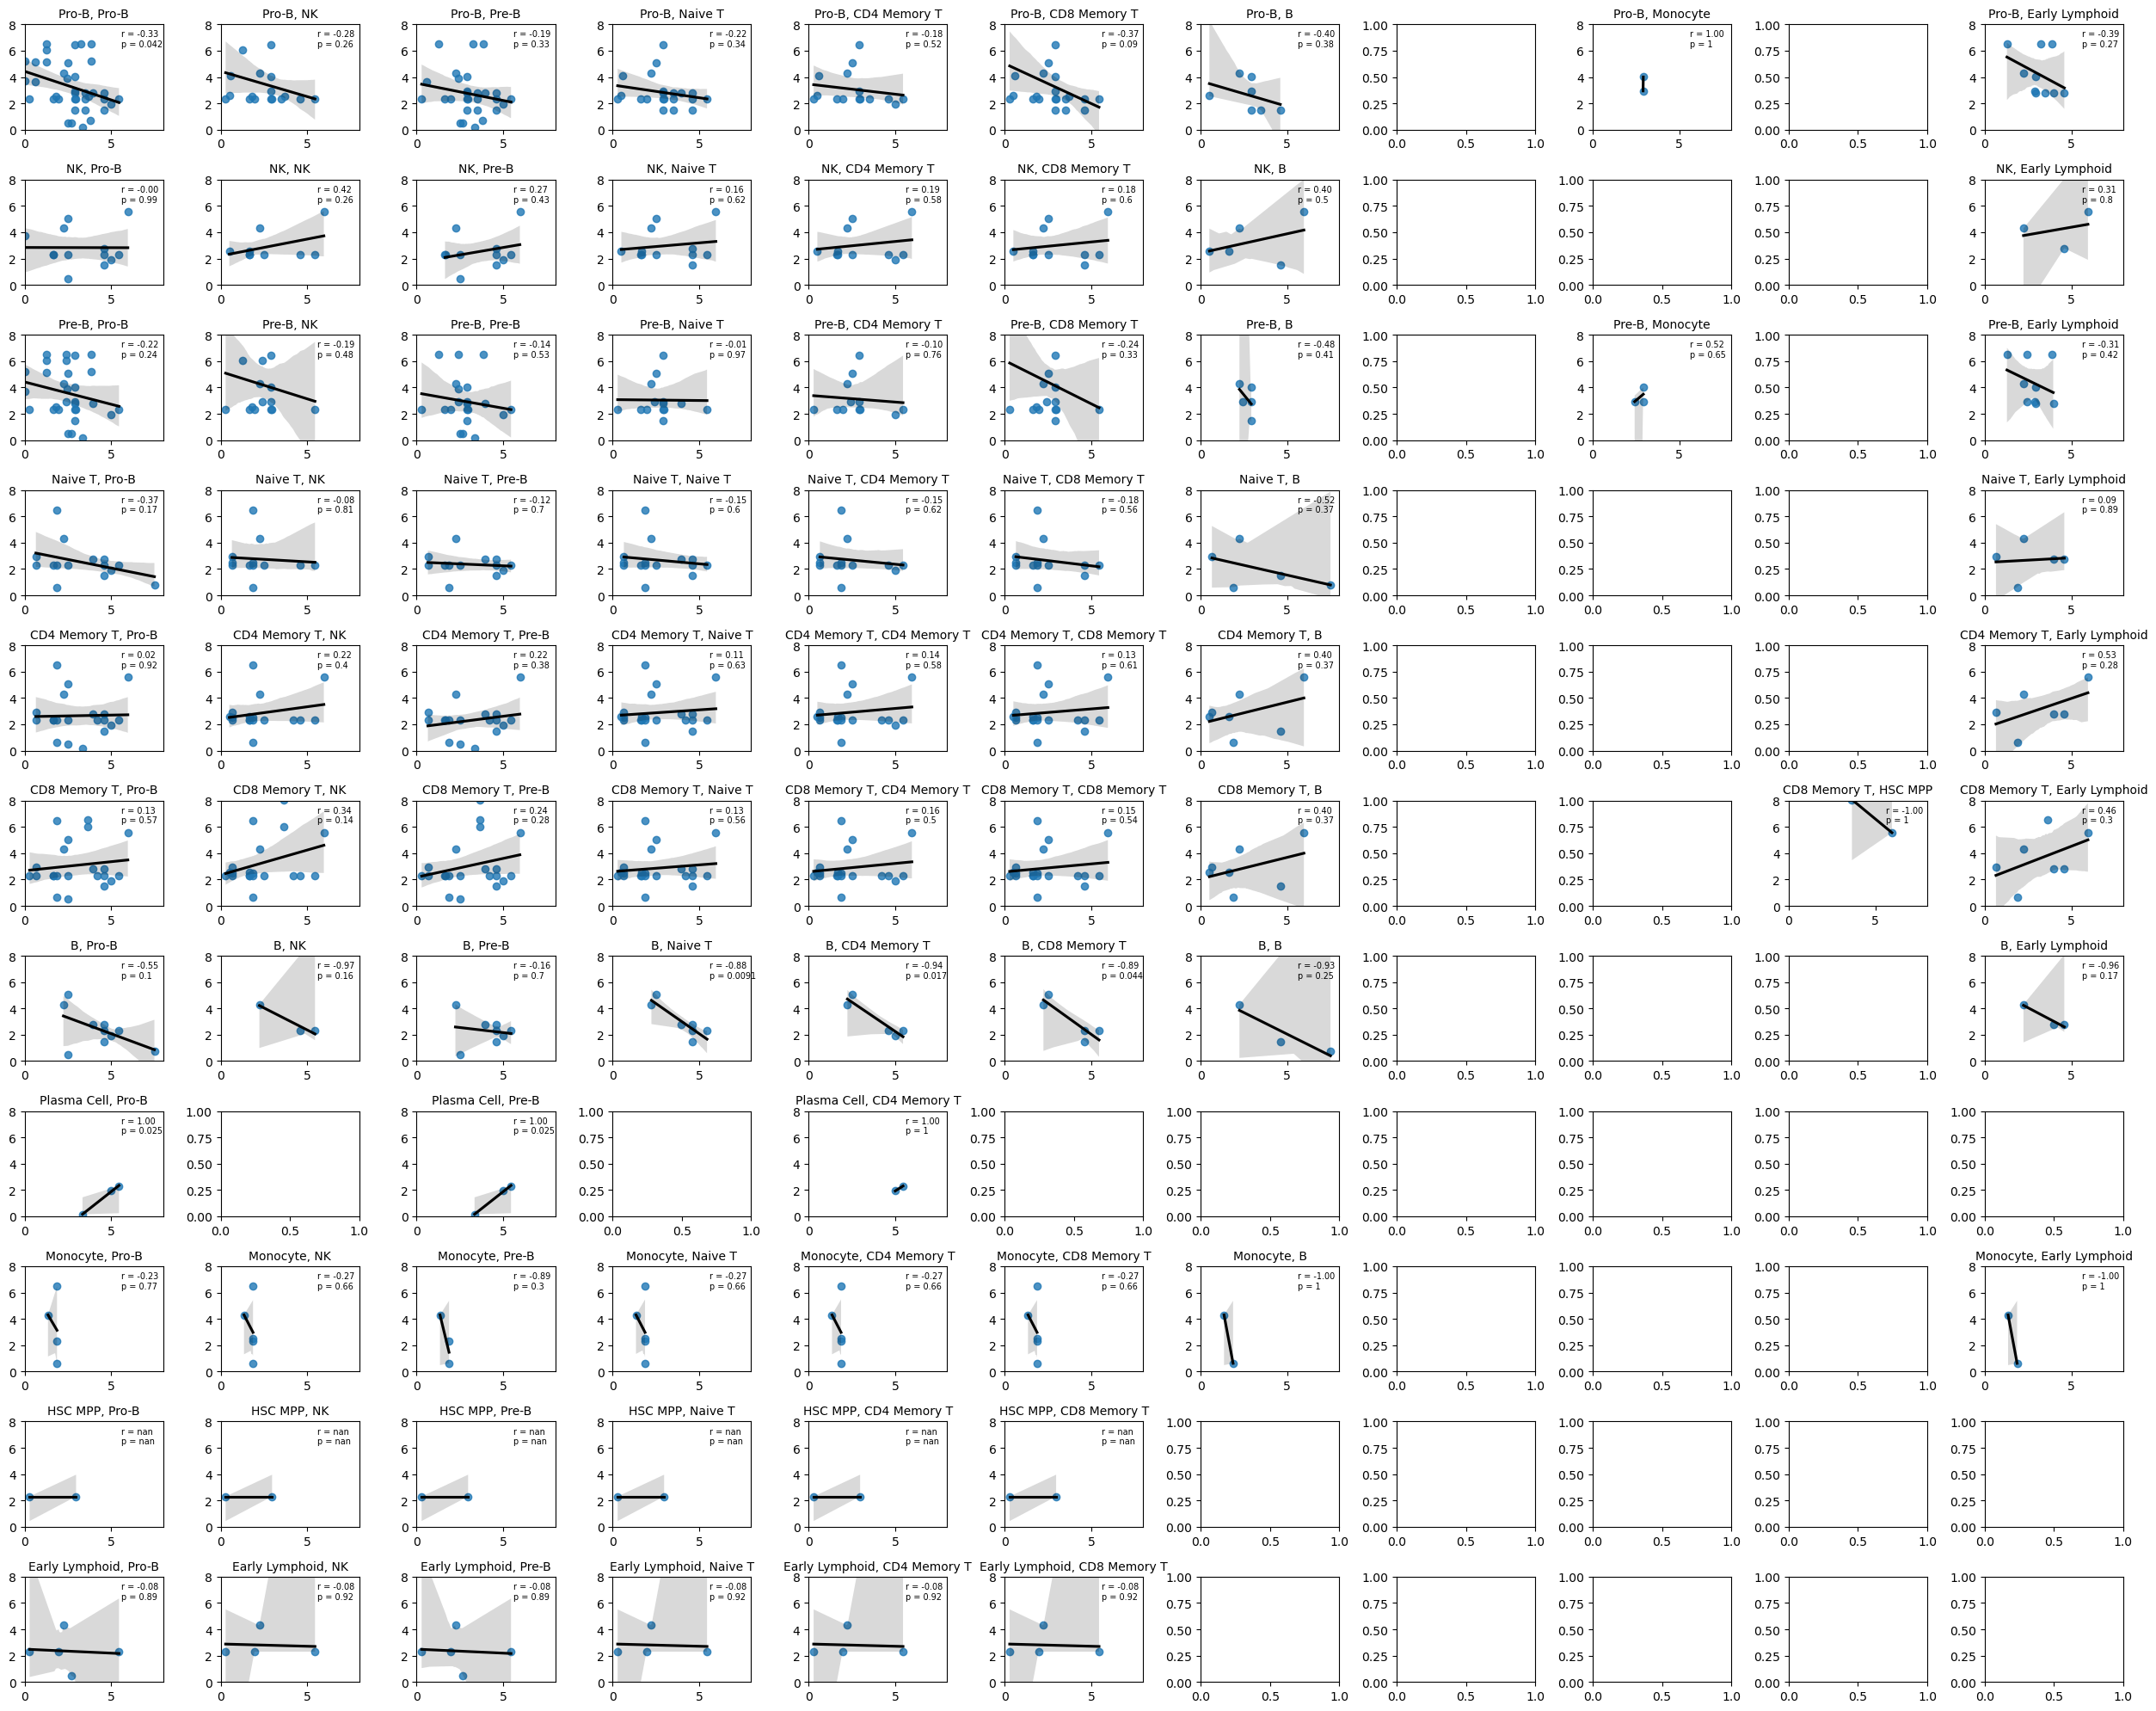

In [ ]:

from scipy.stats import pearsonr
celltype = int_df_d29['target_cell'].unique()
fig, axes = plt.subplots(len(celltype), len(celltype), figsize=(25, 20))

correlations_d29 = []
for x in range(0,len(celltype)):
    i = celltype[x]
    for y in range(len(celltype)):
        j = celltype[y]
        df = int_df_d29[(int_df_d29['target_cell'] == i) & (int_df_d29['source_cell'] == j)]
        cell_pair = f'{i}, {j}'
        
        if len(df) > 1:
            corr, p_value = pearsonr(df['NOL_target'], df['NOL_source'])
            
            sns.regplot(
            x='NOL_target', y='NOL_source', data=df, ax=axes[x, y], line_kws={'color': 'black'})
            axes[x, y].set_title(f'{cell_pair}', size = 10)  
            # axes[x, y].tick_params(labelbottom=False, labelleft=False)
            axes[x, y].set(xlabel=None, ylabel=None)
            axes[x, y].text(0.7, 0.95, f"r = {corr:.2f}\np = {p_value:.2g}", transform=axes[x, y].transAxes,
            ha='left', va='top', fontsize=7)     
            axes[x,y].set_xlim(0,8)   
            axes[x,y].set_ylim(0,8)   
            
        else:
            corr = 0
            p_value = 0
            
        correlations_d29.append({'interaction': cell_pair, 'target':i, 'souce':j, 'correlation' : corr, 'p-val' : p_value})
        
        
correlations_d29 = pd.DataFrame(correlations_d29)   
plt.tight_layout()

In [57]:
correlations_dg

,interaction,target,souce,correlation,p-val
0,"Pro-B, Pro-B",Pro-B,Pro-B,0.138458,0.407102
1,"Pro-B, NK",Pro-B,NK,0.138167,0.584556
2,"Pro-B, Pre-B",Pro-B,Pre-B,0.311575,0.106527
3,"Pro-B, Naive T",Pro-B,Naive T,0.062016,0.789434
4,"Pro-B, CD4 Memory T",Pro-B,CD4 Memory T,0.092893,0.741948
...,...,...,...,...,...
116,"Early Lymphoid, B",Early Lymphoid,B,0.000000,0.000000
117,"Early Lymphoid, Plasma Cell",Early Lymphoid,Plasma Cell,0.000000,0.000000
118,"Early Lymphoid, Monocyte",Early Lymphoid,Monocyte,0.000000,0.000000
119,"Early Lymphoid, HSC MPP",Early Lymphoid,HSC MPP,0.000000,0.000000


In [58]:
correlations_d15

,interaction,target,souce,correlation,p-val
0,"Pro-B, Pro-B",Pro-B,Pro-B,-0.460968,0.003584
1,"Pro-B, NK",Pro-B,NK,-0.432601,0.072963
2,"Pro-B, Pre-B",Pro-B,Pre-B,-0.341731,0.075100
3,"Pro-B, Naive T",Pro-B,Naive T,-0.376603,0.092424
4,"Pro-B, CD4 Memory T",Pro-B,CD4 Memory T,-0.384132,0.157479
...,...,...,...,...,...
116,"Early Lymphoid, B",Early Lymphoid,B,0.000000,0.000000
117,"Early Lymphoid, Plasma Cell",Early Lymphoid,Plasma Cell,0.000000,0.000000
118,"Early Lymphoid, Monocyte",Early Lymphoid,Monocyte,0.000000,0.000000
119,"Early Lymphoid, HSC MPP",Early Lymphoid,HSC MPP,0.000000,0.000000


In [59]:
protein_corr_matrix = correlations.pivot(
    index='souce',
    columns='target',
    values='correlation'
    
).fillna(0)

interacting = (r_binary_matrix==1) & (binary_matrix==1)
protein_prior_matrix = protein_corr_matrix.where(interacting, 0) 
protein_prior_prior = protein_prior_matrix.where(protein_prior_matrix==0, 1)


Text(0.5, 1.0, 'Combined prior matrix')

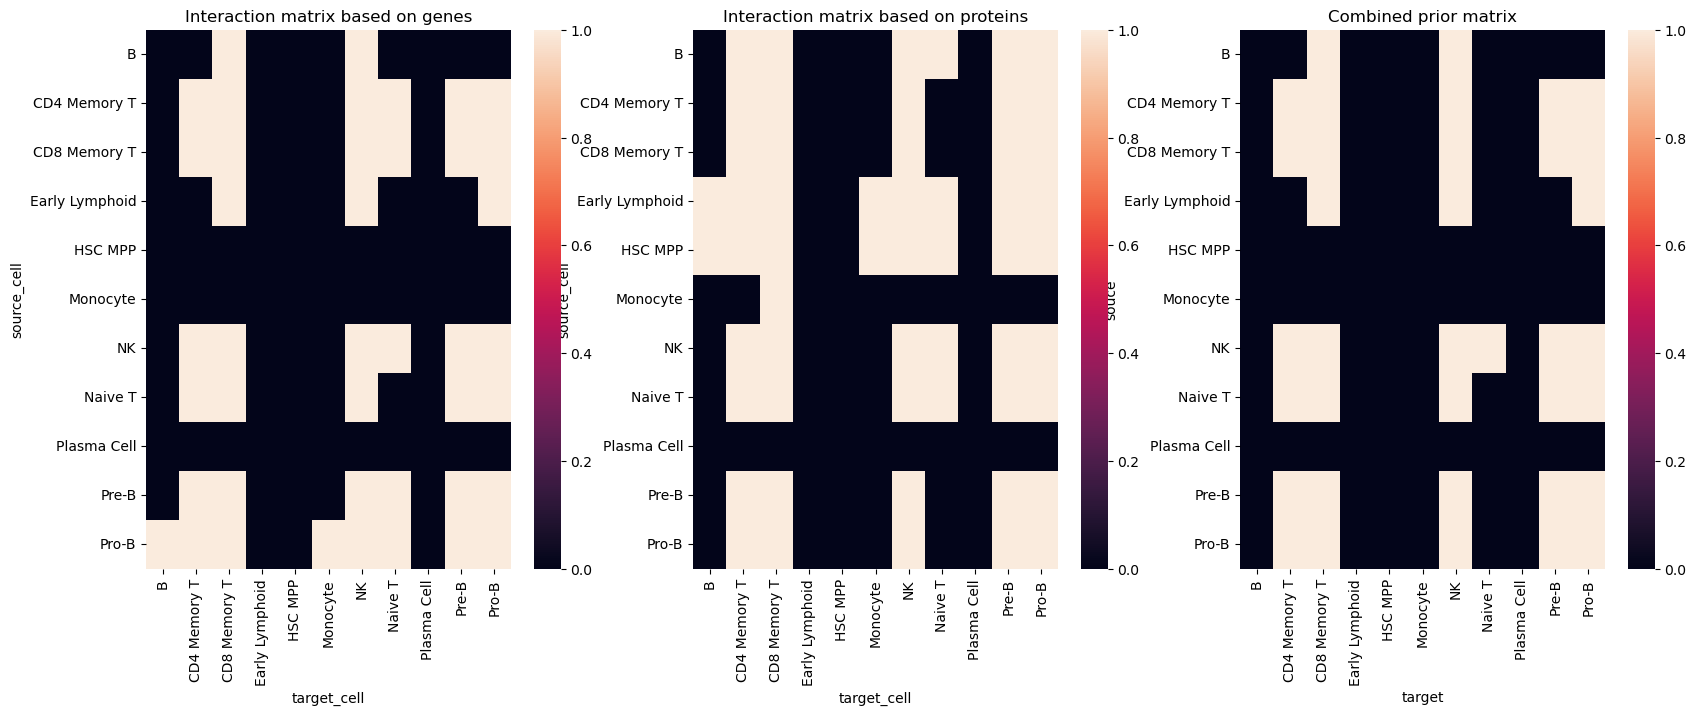

In [60]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sns.heatmap(binary_matrix,ax = axes[0])
sns.heatmap(r_binary_matrix,ax = axes[1])
sns.heatmap(protein_prior_prior,ax = axes[2])
axes[0].set_title('Interaction matrix based on genes')
axes[1].set_title('Interaction matrix based on proteins')
axes[2].set_title('Combined prior matrix')

In [61]:
protein_corr_matrix_dg = correlations_dg.pivot(
    index='souce',
    columns='target',
    values='correlation'
    
).fillna(0)
protein_corr_matrix_dg = protein_corr_matrix_dg.where(interacting, 0) 

protein_corr_matrix_d15 = correlations_d15.pivot(
    index='souce',
    columns='target',
    values='correlation'
    
).fillna(0)
protein_corr_matrix_d15 = protein_corr_matrix_d15.where(interacting, 0) 



Text(0.5, 1.0, 'protein level correlation at day 15')

<Figure size 900x600 with 0 Axes>

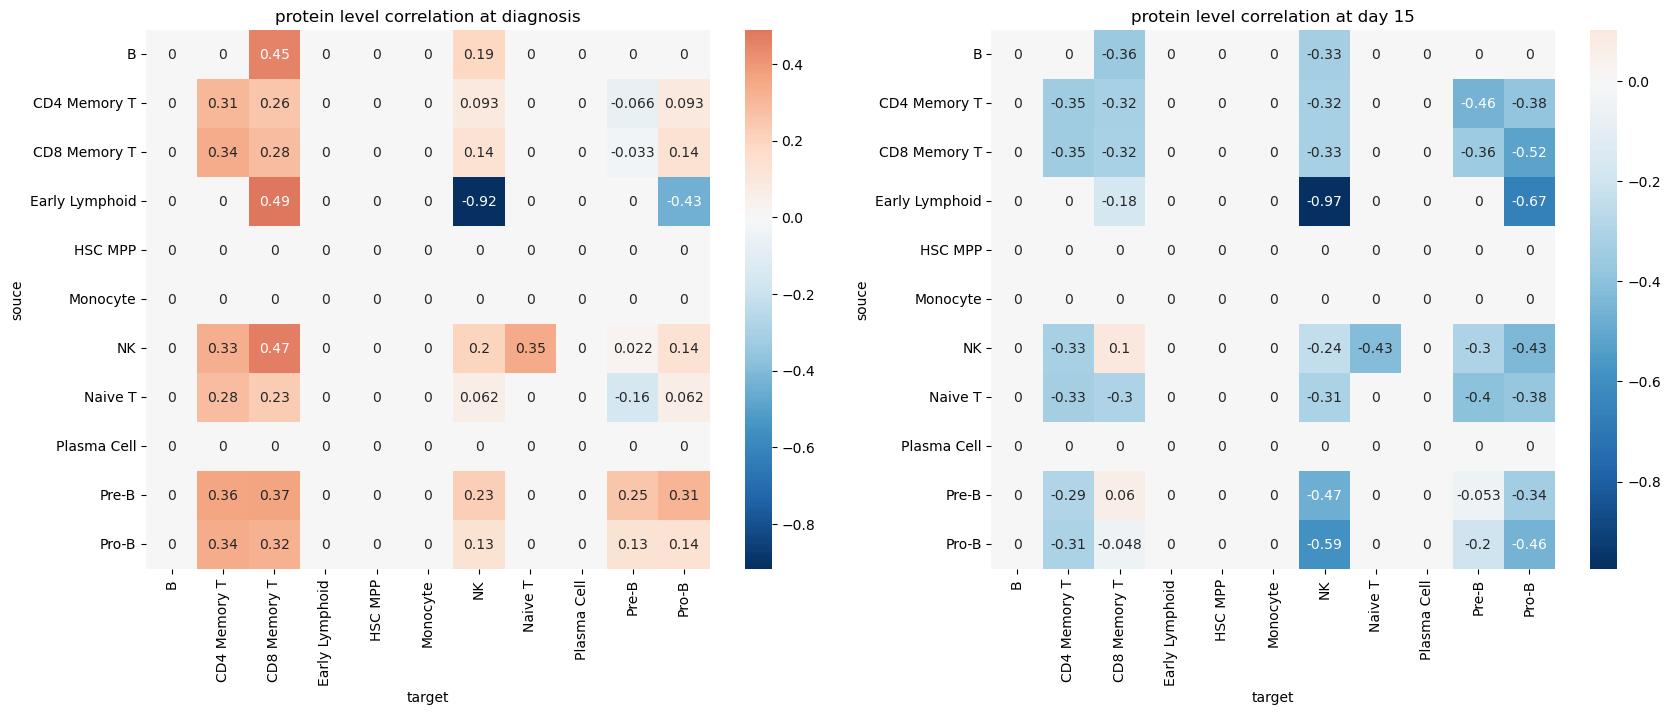

In [62]:
plt.figure(figsize=(9, 6))
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
sns.heatmap(protein_corr_matrix_dg, cmap='RdBu_r',annot=True,ax = axes[0], center= 0)
sns.heatmap(protein_corr_matrix_d15, cmap='RdBu_r',annot=True,ax = axes[1], center=0)
axes[0].set_title('protein level correlation at diagnosis')
axes[1].set_title('protein level correlation at day 15')


In [63]:
P_t = np.stack([protein_corr_matrix_dg,protein_corr_matrix_d15])
P_t.shape

(2, 11, 11)

Based on this we can see that with strict filtration of the protein interactions we could see that the based on the protein infromation same interaction pop up. in later phase this sould be so that the cut of value is based on the interaction found in the gene set and the interaction number should be sertain procent of it to pass as true interaction.



In [64]:
save_path = '/research/groups/bioinformaticians/internship/hhuotari/DIISCO/data/prior_EG11.csv'
binary_matrix.to_csv(save_path)

save_path = '/research/groups/bioinformaticians/internship/hhuotari/DIISCO/data/prior_EG11_prot.csv'
r_binary_matrix.to_csv(save_path) 

In [65]:
save_path = '/research/groups/bioinformaticians/internship/hhuotari/DIISCO/data/W_EG11_16.csv'
W.to_csv(save_path)

In [66]:
save_path = '/research/groups/bioinformaticians/internship/hhuotari/DIISCO/data/real_protein_values.npy'
np.save(save_path,P_t)

In [67]:
save_path = '/research/groups/bioinformaticians/internship/hhuotari/DIISCO/data/int.csv'
protein_prior_prior.to_csv(save_path)